In [ ]:
!pip install tensorflow pandas matplotlib keras

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Config ---

In [ ]:
DATA_DIR_TEGAK = "/content/data/tegak"
DATA_DIR_BUNGKUK = "/content/data/bungkuk"
DATA_DIR_MIRING = "/content/data/miring"
SEQ_LENGTH = 11
N_FEATURES = 6


# --- Load and preprocess CSVs ---

In [ ]:
X = []
y = []

for filename in os.listdir(DATA_DIR_TEGAK):
    if filename.endswith(".csv"):
        filepath = os.path.join(DATA_DIR_TEGAK, filename)
        label = 'tegak'
        df = pd.read_csv(filepath)
        data = df[['Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']].values

        X.append(data)
        y.append(label)

for filename in os.listdir(DATA_DIR_BUNGKUK):
    if filename.endswith(".csv"):
        filepath = os.path.join(DATA_DIR_BUNGKUK, filename)
        label = 'bungkuk'
        df = pd.read_csv(filepath)
        data = df[['Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']].values

        X.append(data)
        y.append(label)

for filename in os.listdir(DATA_DIR_MIRING):
    if filename.endswith(".csv"):
        filepath = os.path.join(DATA_DIR_MIRING, filename)
        label = 'miring'
        df = pd.read_csv(filepath)
        data = df[['Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']].values

        X.append(data)
        y.append(label)

X = np.array(X)  # shape: (samples, timesteps, features)
print(f"X shape: {X.shape}")

X shape: (245, 15, 6)


# --- Encode labels ---

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# --- Build CNN (1D) model ---

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense

model = Sequential([
    Input(shape=(12, 6)),  # (timesteps=12, features=6)
    Conv1D(16, kernel_size=3, activation='relu'),       # Very small Conv layer
    GlobalAveragePooling1D(),                          # Replaces Flatten to reduce params
    Dense(3, activation='softmax')                     # Final classification layer
])

model = Sequential([
    Conv1D(16, kernel_size=3, activation='tanh', input_shape=(11, 6)),
    GlobalAveragePooling1D(),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])


model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 10, 16)         │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467 (1.82 KB)

 Trainable params: 467 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

# --- Train model ---

In [ ]:
history = model.fit(X, y_cat, epochs=20, batch_size=8, validation_split=0.2)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4821 - loss: 0.9371 - val_accuracy: 0.7347 - val_loss: 0.5881
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7627 - loss: 0.4936 - val_accuracy: 0.7959 - val_loss: 0.4527
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8484 - loss: 0.3584 - val_accuracy: 0.7959 - val_loss: 0.3953
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8091 - loss: 0.3625 - val_accuracy: 0.8163 - val_loss: 0.3502
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8198 - loss: 0.3387 - val_accuracy: 0.8163 - val_loss: 0.3169
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8518 - loss: 0.2495 - val_accuracy: 0.8163 - val_loss: 0.2886
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8419 - loss: 0.2502 - val_accuracy: 0.8163 - val_loss: 0.2638
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8314 - loss: 0.2231 - val_accuracy: 0.8163 - val_loss

# --- Plot training history ---

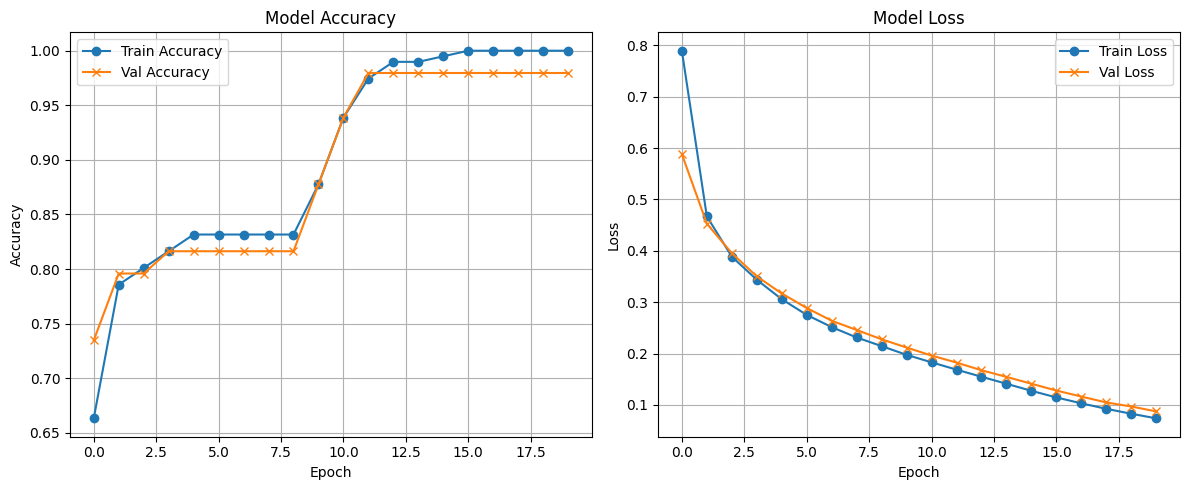

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Save model ---

In [ ]:
model.save("boxing_lstm_model.h5")


# --- Convert to TFLite (float) ---

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

# Optional quantization (still okay to keep)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("boxing_model.tflite", "wb") as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmp48ifsiv5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 6), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132259762176272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132259762179344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132259762178768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132259762180112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132259762179536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132259762180880: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
import flatbuffers
import os
from tensorflow.lite.python import schema_py_generated as schema

# Load model
with open("boxing_model.tflite", "rb") as f:
    buf = f.read()

model = schema.Model.GetRootAsModel(buf, 0)

# TFLite BuiltinOperator enum (manually mapped for readability)
builtin_op_map = {v: k for k, v in schema.BuiltinOperator.__dict__.items() if isinstance(v, int)}

print("=== Operators in the model ===")
for i in range(model.OperatorCodesLength()):
    op_code = model.OperatorCodes(i)
    builtin_code = op_code.BuiltinCode()
    if builtin_code == schema.BuiltinOperator.CUSTOM:
        print(f"[CUSTOM] {op_code.CustomCode().decode('utf-8')}")
    else:
        op_name = builtin_op_map.get(builtin_code, f"Unknown({builtin_code})")
        print(f"[BUILTIN] {op_name}")


=== Operators in the model ===
[BUILTIN] EXPAND_DIMS
[BUILTIN] CONV_2D
[BUILTIN] TANH
[BUILTIN] RESHAPE
[BUILTIN] MEAN
[BUILTIN] FULLY_CONNECTED
[BUILTIN] SOFTMAX
